# Visualization


In [437]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
farmer = pd.read_csv('farmer.csv')
rice_miller = pd.read_csv('rice_miller.csv')
middlemen = pd.read_csv('middlemen.csv')
wholesaler = pd.read_csv('wholesaler.csv')
retail = pd.read_csv('retail.csv')

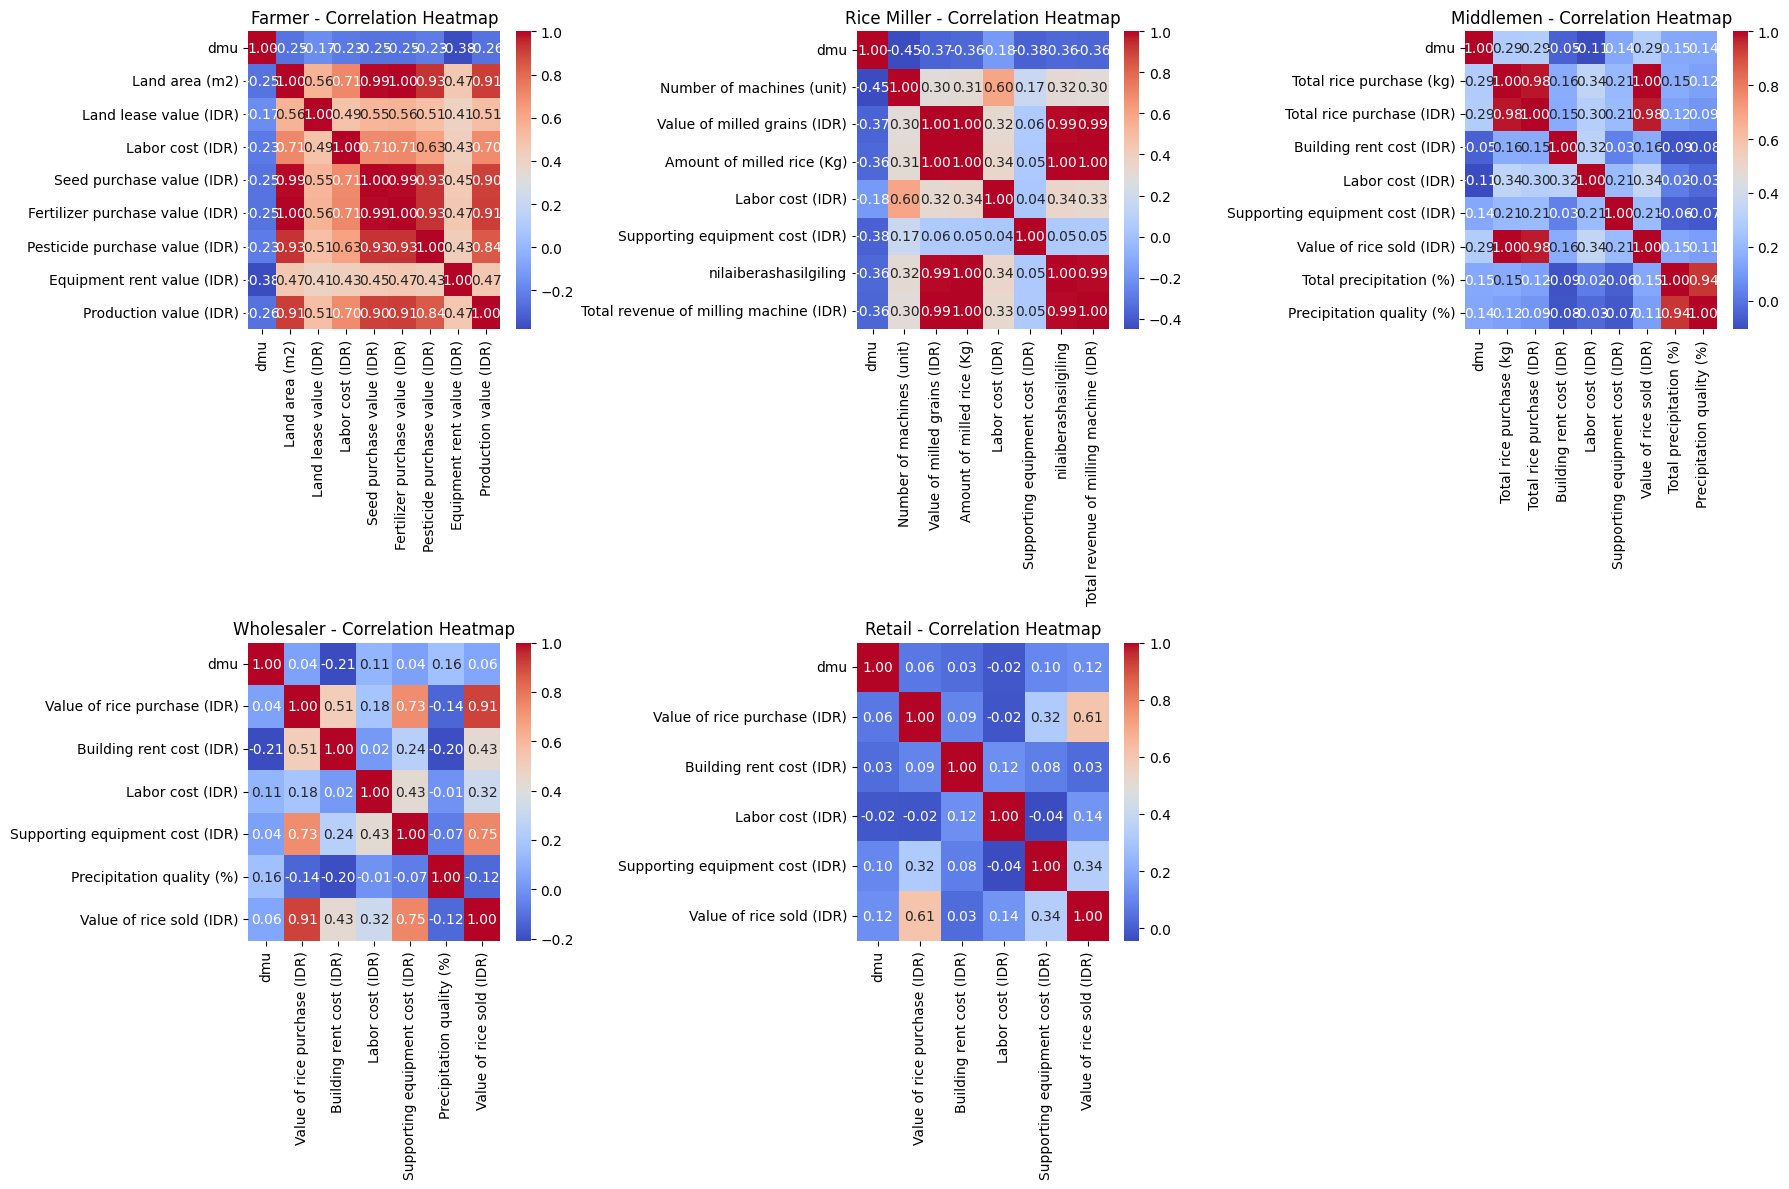

In [ ]:
dataframes = {
    'Farmer': farmer,
    'Rice Miller': rice_miller,
    'Middlemen': middlemen,
    'Wholesaler': wholesaler,
    'Retail': retail
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, df) in enumerate(dataframes.items()):
    numeric_df = df.select_dtypes(include=[np.number])
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[idx])
    axes[idx].set_title(f'{name} - Correlation Heatmap')

# Hide the extra subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

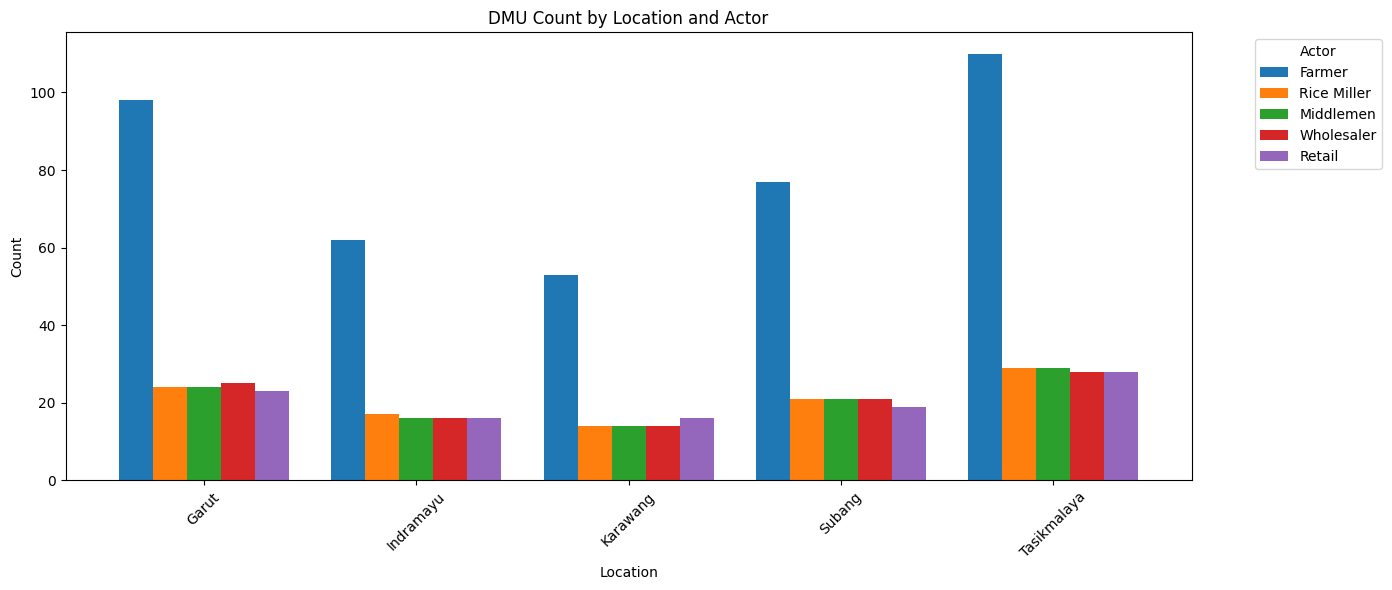

In [353]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# Create a dictionary to store counts for each location and actor
location_data = {}
for location in farmer['Location'].unique():
    location_data[location] = {}
    for name, df in dataframes.items():
        location_data[location][name] = len(df[df['Location'] == location])

# Convert to DataFrame for easier plotting
location_df = pd.DataFrame(location_data).T

# Plot grouped bar chart
location_df.plot(kind='bar', ax=axes, width=0.8)
axes.set_title('DMU Count by Location and Actor')
axes.set_xlabel('Location')
axes.set_ylabel('Count')
axes.legend(title='Actor', bbox_to_anchor=(1.05, 1), loc='upper left')
axes.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [394]:
farmer.groupby('Location')['Production value (IDR)'].mean().values


array([1.87460102e+07, 5.57480645e+07, 1.09004755e+08, 4.20194090e+07,
       2.02044455e+07])

In [410]:
data = [
  farmer.groupby('Location')['Production value (IDR)'].mean().values,
  rice_miller.groupby('Location')['Value of milled grains (IDR)'].mean().values,
  rice_miller.groupby('Location')['nilaiberashasilgiling'].mean().values,
  middlemen.groupby('Location')['Total rice purchase (IDR)'].mean().values,
  middlemen.groupby('Location')['Value of rice sold (IDR)'].mean().values,
  wholesaler.groupby('Location')['Value of rice purchase (IDR)'].mean().values,
  wholesaler.groupby('Location')['Value of rice sold (IDR)'].mean().values,
  retail.groupby('Location')['Value of rice purchase (IDR)'].mean().values,
  retail.groupby('Location')['Value of rice sold (IDR)'].mean().values,
]

# Create DataFrame with headers
price_spread = pd.DataFrame(data)
price_spread = price_spread.T
price_spread.columns = ["Farmer Sell", "Rice Miller Purchase", "Rice Miller Sell", "Middlemen Purchase", "Middlemen Sell", "Wholesaler Purchase", "Wholesaler Sell", "Retail Purchase", "Retail Sell"]
price_spread.insert(loc=0, column='Locations', value=['Garut', 'Indramayu', 'Karawang', 'Subang', 'Sumedang'])
price_spread


,Locations,Farmer Sell,Rice Miller Purchase,Rice Miller Sell,Middlemen Purchase,Middlemen Sell,Wholesaler Purchase,Wholesaler Sell,Retail Purchase,Retail Sell
0,Garut,1.874601e+07,1.061021e+08,1.271632e+08,3.906833e+07,3.885667e+07,1.153200e+08,1.175160e+08,2.496087e+06,3.215217e+06
1,Indramayu,5.574806e+07,8.555159e+08,1.046645e+09,1.477344e+08,1.805938e+08,1.496625e+09,2.315038e+09,2.294844e+06,2.770750e+06
2,Karawang,1.090048e+08,1.556500e+08,1.536759e+08,7.542500e+07,8.886071e+07,2.748071e+08,3.696071e+08,2.485312e+06,2.837500e+06
3,Subang,4.201941e+07,2.005143e+08,2.509387e+08,1.247833e+08,1.590848e+08,1.377857e+08,2.410937e+08,2.307237e+06,2.696053e+06
4,Sumedang,2.020445e+07,1.117659e+08,1.219328e+08,5.160522e+07,5.214207e+07,2.598993e+08,6.112525e+08,2.579375e+06,2.973393e+06


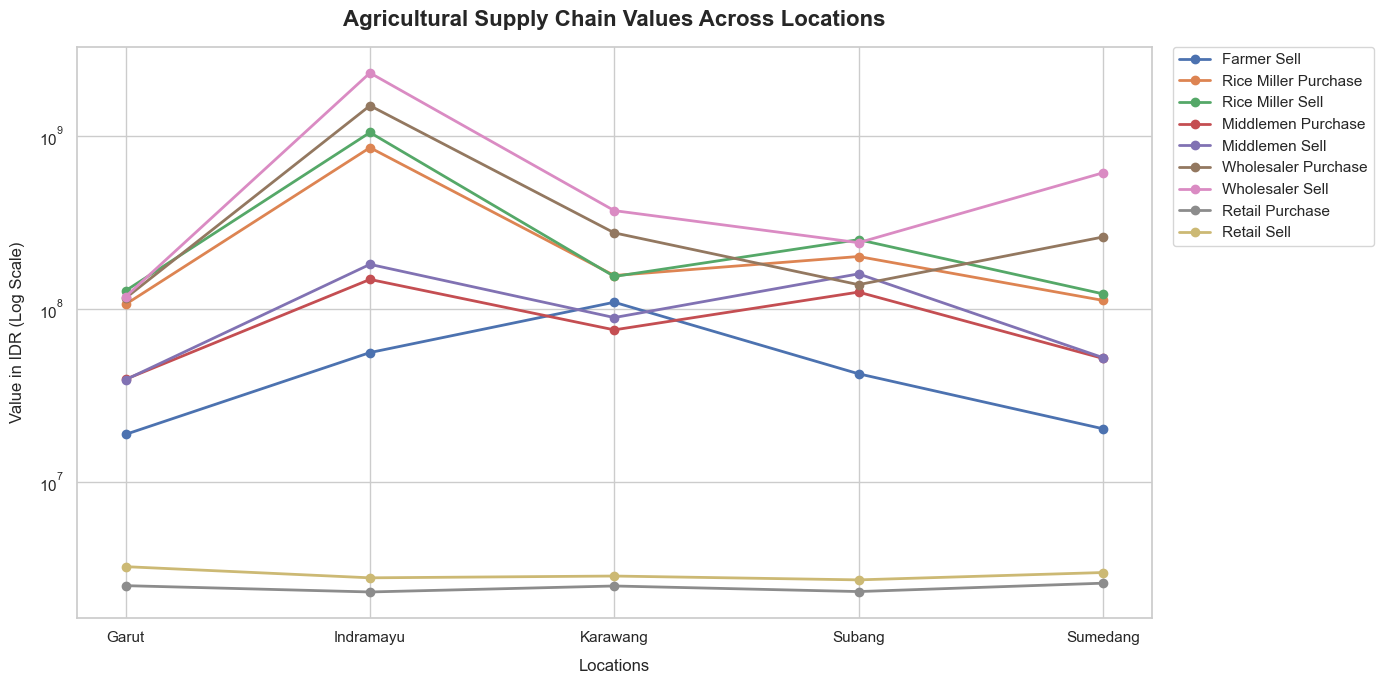

In [424]:
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# 3. Loop through columns and plot each line
for column in price_spread.columns:
    if column != 'Locations':
        plt.plot(price_spread['Locations'], price_spread[column], marker='o', linewidth=2, label=column)

# 4. Styling adjustments
plt.title('Agricultural Supply Chain Values Across Locations', fontsize=16, pad=15, weight='bold')
plt.xlabel('Locations', fontsize=12, labelpad=10)
plt.ylabel('Value in IDR (Log Scale)', fontsize=12, labelpad=10)

# Use Logarithmic scale because of the massive difference between Retail and Wholesaler values
plt.yscale('log')

# Place legend cleanly outside the main frame
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=11)
plt.tight_layout()

plt.show()

In [426]:
price_spread

,Locations,Farmer Sell,Rice Miller Purchase,Rice Miller Sell,Middlemen Purchase,Middlemen Sell,Wholesaler Purchase,Wholesaler Sell,Retail Purchase,Retail Sell,Rice Miller Margin,Middlemen Margin,Wholesaler Margin,Retail Margin
0,Garut,1.874601e+07,1.061021e+08,1.271632e+08,3.906833e+07,3.885667e+07,1.153200e+08,1.175160e+08,2.496087e+06,3.215217e+06,2.106111e+07,-2.116667e+05,2.196000e+06,719130.434783
1,Indramayu,5.574806e+07,8.555159e+08,1.046645e+09,1.477344e+08,1.805938e+08,1.496625e+09,2.315038e+09,2.294844e+06,2.770750e+06,1.911296e+08,3.285938e+07,8.184125e+08,475906.250000
2,Karawang,1.090048e+08,1.556500e+08,1.536759e+08,7.542500e+07,8.886071e+07,2.748071e+08,3.696071e+08,2.485312e+06,2.837500e+06,-1.974050e+06,1.343571e+07,9.480000e+07,352187.500000
3,Subang,4.201941e+07,2.005143e+08,2.509387e+08,1.247833e+08,1.590848e+08,1.377857e+08,2.410937e+08,2.307237e+06,2.696053e+06,5.042437e+07,3.430143e+07,1.033080e+08,388815.789474
4,Sumedang,2.020445e+07,1.117659e+08,1.219328e+08,5.160522e+07,5.214207e+07,2.598993e+08,6.112525e+08,2.579375e+06,2.973393e+06,1.016693e+07,5.368455e+05,3.513532e+08,394017.857143


   Locations  Rice Miller Margin  Middlemen Margin  Wholesaler Margin  Retail Margin
0      Garut        2.106111e+07     -2.116667e+05       2.196000e+06  719130.434783
1  Indramayu        1.911296e+08      3.285938e+07       8.184125e+08  475906.250000
2   Karawang       -1.974050e+06      1.343571e+07       9.480000e+07  352187.500000
3     Subang        5.042437e+07      3.430143e+07       1.033080e+08  388815.789474
4   Sumedang        1.016693e+07      5.368455e+05       3.513532e+08  394017.857143


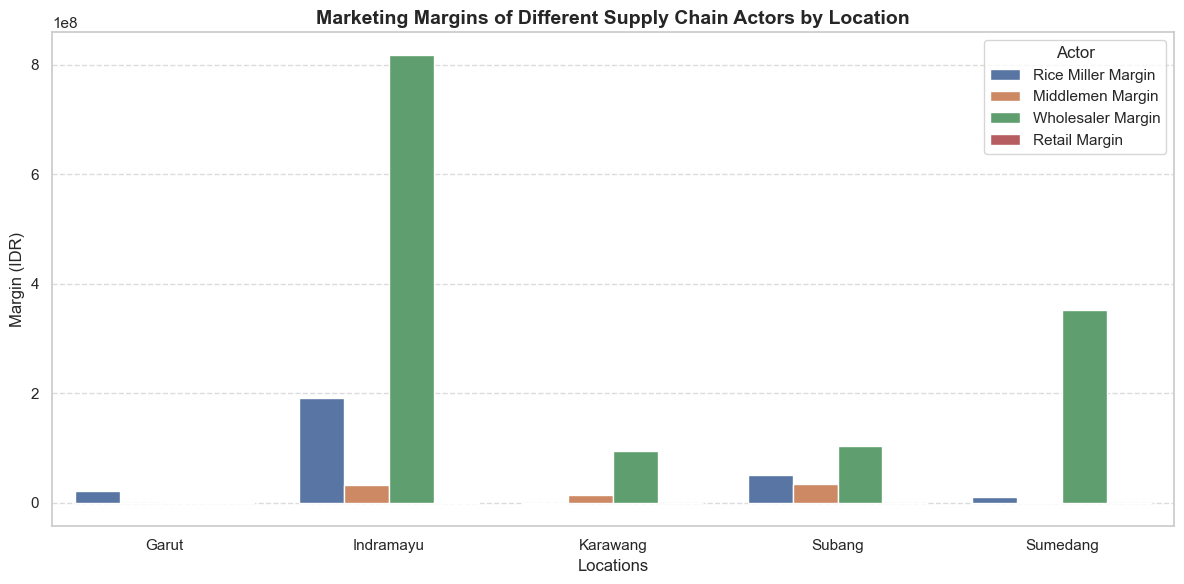

In [435]:
# Calculate marketing margins (Sell - Purchase)
price_spread['Rice Miller Margin'] = price_spread['Rice Miller Sell'] - price_spread['Rice Miller Purchase']
price_spread['Middlemen Margin'] = price_spread['Middlemen Sell'] - price_spread['Middlemen Purchase']
price_spread['Wholesaler Margin'] = price_spread['Wholesaler Sell'] - price_spread['Wholesaler Purchase']
price_spread['Retail Margin'] = price_spread['Retail Sell'] - price_spread['Retail Purchase']

margin_cols = ['Locations', 'Rice Miller Margin', 'Middlemen Margin', 'Wholesaler Margin', 'Retail Margin']
print(price_spread[margin_cols].to_string())

# Let's melt the dataframe for plotting
df_melted = price_spread.melt(id_vars='Locations', value_vars=['Rice Miller Margin', 'Middlemen Margin', 'Wholesaler Margin', 'Retail Margin'],
                    var_name='Actor', value_name='Margin (IDR)')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Locations', y='Margin (IDR)', hue='Actor')
plt.title('Marketing Margins of Different Supply Chain Actors by Location', fontsize=14, weight='bold')
plt.ylabel('Margin (IDR)')
plt.xlabel('Locations')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Anomaly


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# 2. Harmonize and calculate unit prices/proxies for each actor tier
# Farmer: Production Value / Estimated Yield (We can use a proxy metric or look at value density)
farmer['price_metric'] = farmer['Production value (IDR)'] / farmer['Land area (m2)']
farmer['Actor_Type'] = 'Farmer'

rice_miller['price_metric'] = rice_miller['nilaiberashasilgiling'] / rice_miller['Amount of milled rice (Kg)']
rice_miller['Actor_Type'] = 'Rice Miller'

middlemen['price_metric'] = middlemen['Value of rice sold (IDR)'] / middlemen['Total rice purchase (kg)']
middlemen['Actor_Type'] = 'Middleman'

wholesaler['price_metric'] = wholesaler['Value of rice sold (IDR)'] / wholesaler['Value of rice purchase (IDR)']
wholesaler['Actor_Type'] = 'Wholesaler'

retail['price_metric'] = retail['Value of rice sold (IDR)'] / retail['Value of rice purchase (IDR)']
retail['Actor_Type'] = 'Retail'

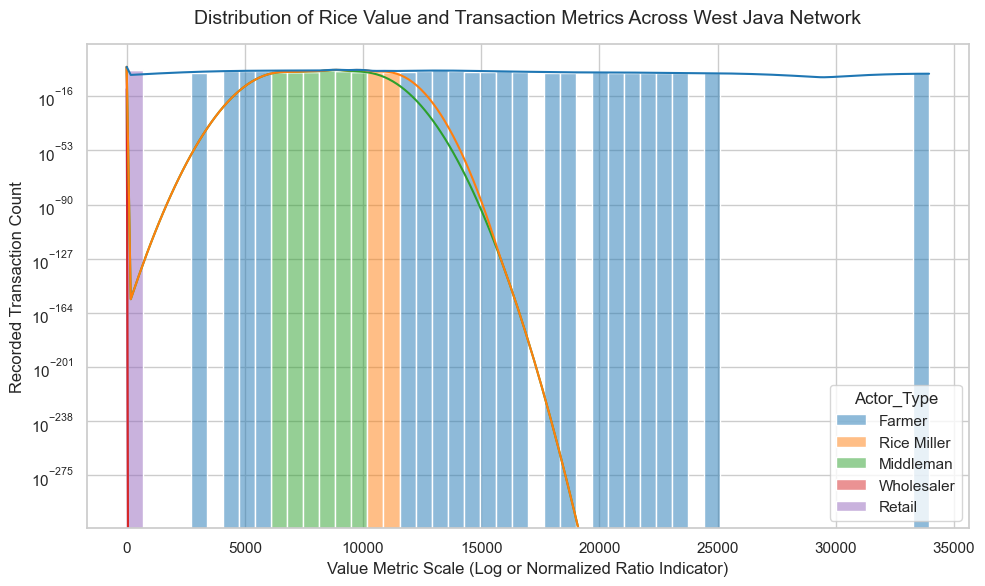

In [5]:
# 3. Combine into a master analytical dataframe for cross-sectional plotting
# We keep only the metrics common across all actors for this visual phase
columns_to_keep = ['Location', 'Actor_Type', 'price_metric']
master_df = pd.concat([
    farmer[columns_to_keep],
    rice_miller[columns_to_keep],
    middlemen[columns_to_keep],
    wholesaler[columns_to_keep],
    retail[columns_to_keep]
], ignore_index=True)

# Rename 'Location' to 'Regency' for clarity in the presentation
master_df.rename(columns={'Location': 'Regency'}, inplace=True)

# Clean up infinite values or extreme zeros caused by unentered data
master_df = master_df[np.isfinite(master_df['price_metric']) & (master_df['price_metric'] > 0)]

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# =====================================================================
# CHART 1: HISTOGRAM OF ECONOMIC VALUE METRICS
# =====================================================================
plt.figure(figsize=(10, 6))
sns.histplot(data=master_df, x='price_metric', hue='Actor_Type', kde=True, multiple="stack", palette="tab10", bins=50)

plt.title('Distribution of Rice Value and Transaction Metrics Across West Java Network', pad=15)
plt.xlabel('Value Metric Scale (Log or Normalized Ratio Indicator)')
plt.ylabel('Recorded Transaction Count')
plt.yscale('log') # Log scale helps handle the massive gap between small farms and macro wholesalers
plt.tight_layout()
plt.show()

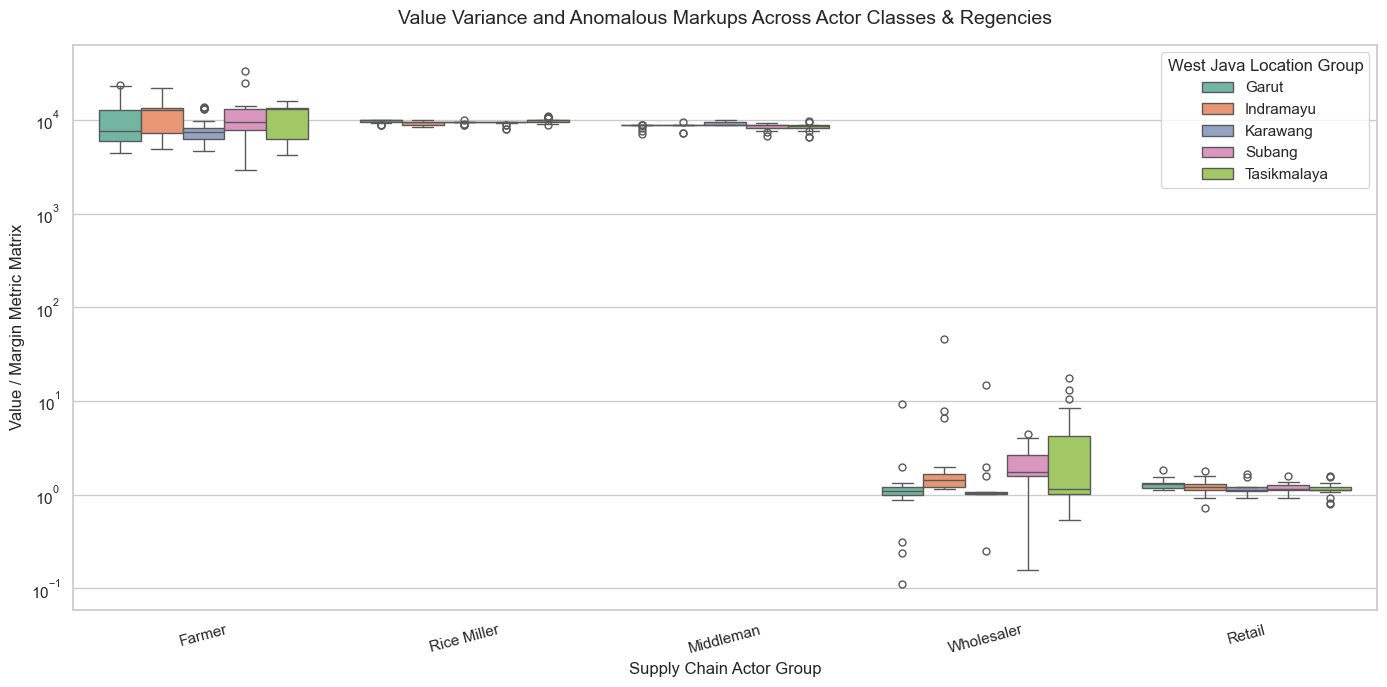

In [6]:
# =====================================================================
# CHART 2: REGIONAL BOX PLOT FOR ANOMALY IDENTIFICATION
# =====================================================================
plt.figure(figsize=(14, 7))
actor_order = ['Farmer', 'Rice Miller', 'Middleman', 'Wholesaler', 'Retail']

sns.boxplot(
    data=master_df, 
    x='Actor_Type', 
    y='price_metric', 
    hue='Regency', 
    order=actor_order,
    palette='Set2',
    fliersize=5
)

plt.title('Value Variance and Anomalous Markups Across Actor Classes & Regencies', pad=15)
plt.xlabel('Supply Chain Actor Group')
plt.ylabel('Value / Margin Metric Matrix')
plt.yscale('log') # Kept to maintain scalability across different unit columns
plt.xticks(rotation=15)
plt.legend(title='West Java Location Group', loc='upper right')
plt.tight_layout()
plt.show()

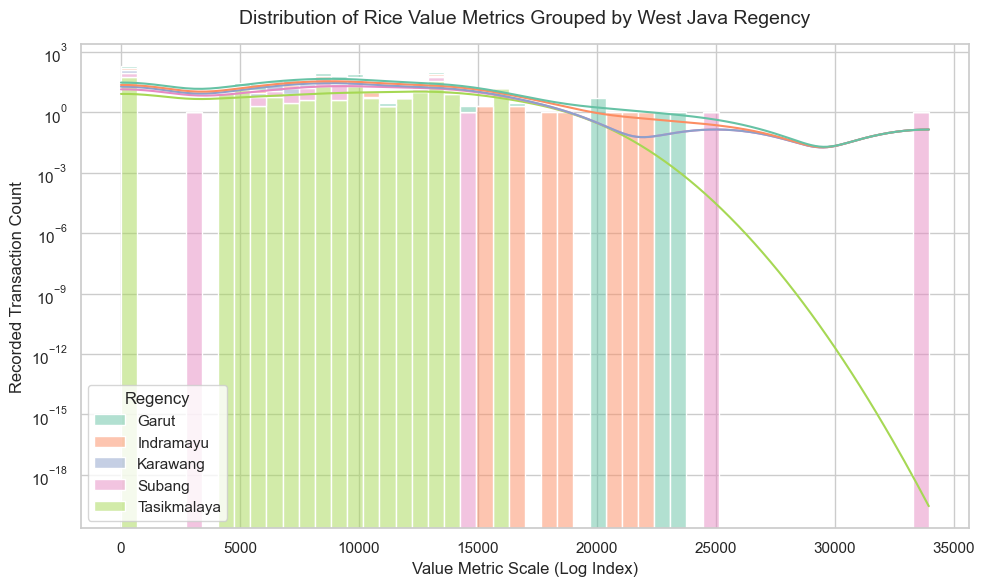

In [15]:
# =====================================================================
# REVISED CHART 1: HISTOGRAM (Grouped by Regency)
# =====================================================================
plt.figure(figsize=(10, 6))
sns.histplot(data=master_df, x='price_metric', hue='Regency', kde=True, multiple="stack", palette="Set2", bins=50)

plt.title('Distribution of Rice Value Metrics Grouped by West Java Regency', pad=15)
plt.xlabel('Value Metric Scale (Log Index)')
plt.ylabel('Recorded Transaction Count')
plt.yscale('log')
plt.tight_layout()
plt.show()

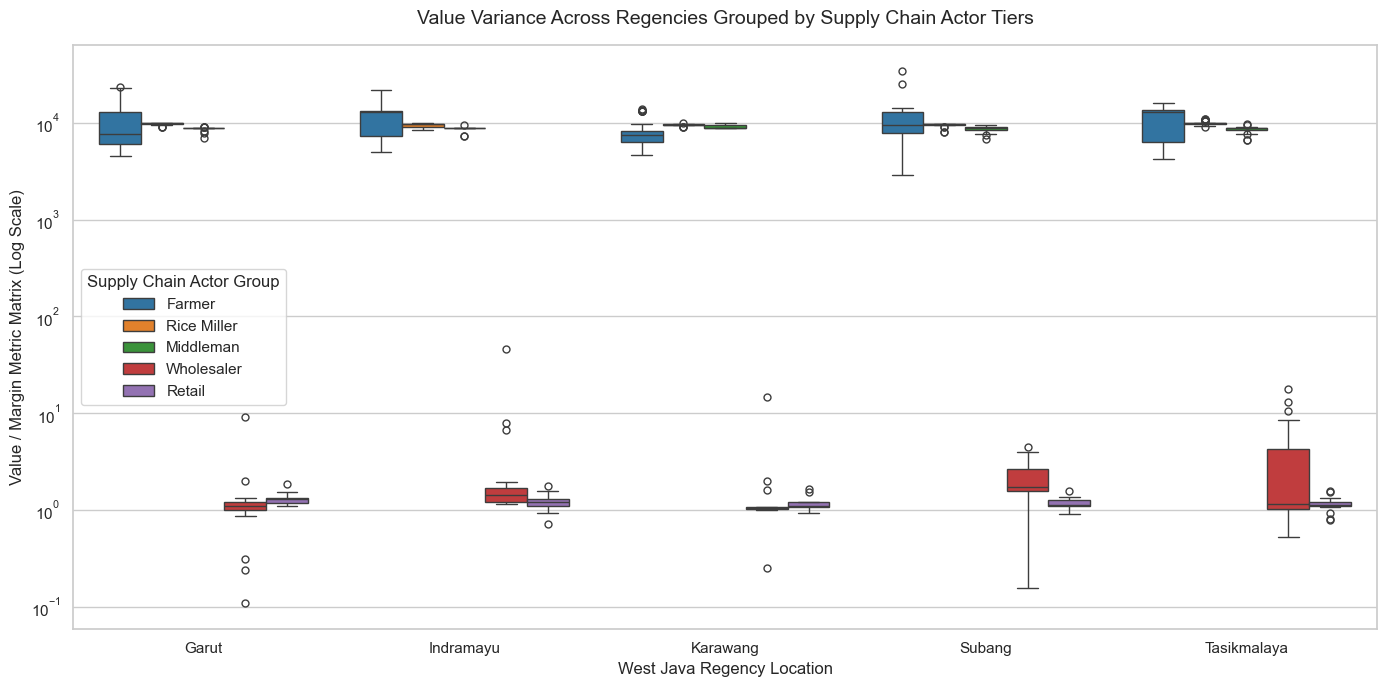

In [18]:
# =====================================================================
# REVISED CHART 2: BOX PLOT (X-Axis = Regency, Hue = Actor Type)
# =====================================================================
plt.figure(figsize=(14, 7))

# Establish strict alphabetical order for locations and logical supply chain flow for actors
regency_order = sorted(master_df['Regency'].unique())
actor_order = ['Farmer', 'Rice Miller', 'Middleman', 'Wholesaler', 'Retail']

sns.boxplot(
    data=master_df, 
    x='Regency', 
    y='price_metric', 
    hue='Actor_Type', 
    order=regency_order,
    hue_order=actor_order,
    palette='tab10',
    fliersize=5
)

plt.title('Value Variance Across Regencies Grouped by Supply Chain Actor Tiers', pad=15)
plt.xlabel('West Java Regency Location')
plt.ylabel('Value / Margin Metric Matrix (Log Scale)')
plt.yscale('log')
plt.legend(title='Supply Chain Actor Group', loc='best')
plt.tight_layout()
plt.show()

In [20]:
# =====================================================================
# PHYSICAL SCALE ANALYSIS (Middlemen)
# =====================================================================
middlemen['unit_price_sold'] = middlemen['Value of rice sold (IDR)'] / middlemen['Total rice purchase (kg)']
middlemen['log_volume_kg'] = np.log1p(middlemen['Total rice purchase (kg)'])

# Feature: Ratio of price to log volume
middlemen['physical_scale_index'] = middlemen['unit_price_sold'] / middlemen['log_volume_kg']

# =====================================================================
# CAPITAL SCALE ANALYSIS (Wholesalers)
# =====================================================================
wholesaler['roi_multiplier'] = wholesaler['Value of rice sold (IDR)'] / wholesaler['Value of rice purchase (IDR)']
wholesaler['log_capital_purchase'] = np.log10(wholesaler['Value of rice purchase (IDR)'])

# Feature: ROI relative to the size of the capital deployed
wholesaler['capital_scale_index'] = wholesaler['roi_multiplier'] / wholesaler['log_capital_purchase']

# 2. Extract Top 5 Exploitative Capital Scale Anomalies for the Report Table
top_wholesaler_anomalies = wholesaler.sort_values(by='capital_scale_index', ascending=False).head(5)

print("=== CRITICAL CAPITAL SCALE ANOMALIES (WHOLESALER) ===")
top_wholesaler_anomalies[['Location', 'Value of rice purchase (IDR)', 'Value of rice sold (IDR)', 'roi_multiplier']]

=== CRITICAL CAPITAL SCALE ANOMALIES (WHOLESALER) ===


,Location,Value of rice purchase (IDR),Value of rice sold (IDR),roi_multiplier
37,Indramayu,114000000.0,5.292000e+09,46.421053
88,Tasikmalaya,114000000.0,2.016000e+09,17.684211
46,Karawang,114000000.0,1.692000e+09,14.842105
87,Tasikmalaya,114000000.0,1.504000e+09,13.192982
96,Tasikmalaya,114000000.0,1.200000e+09,10.526316


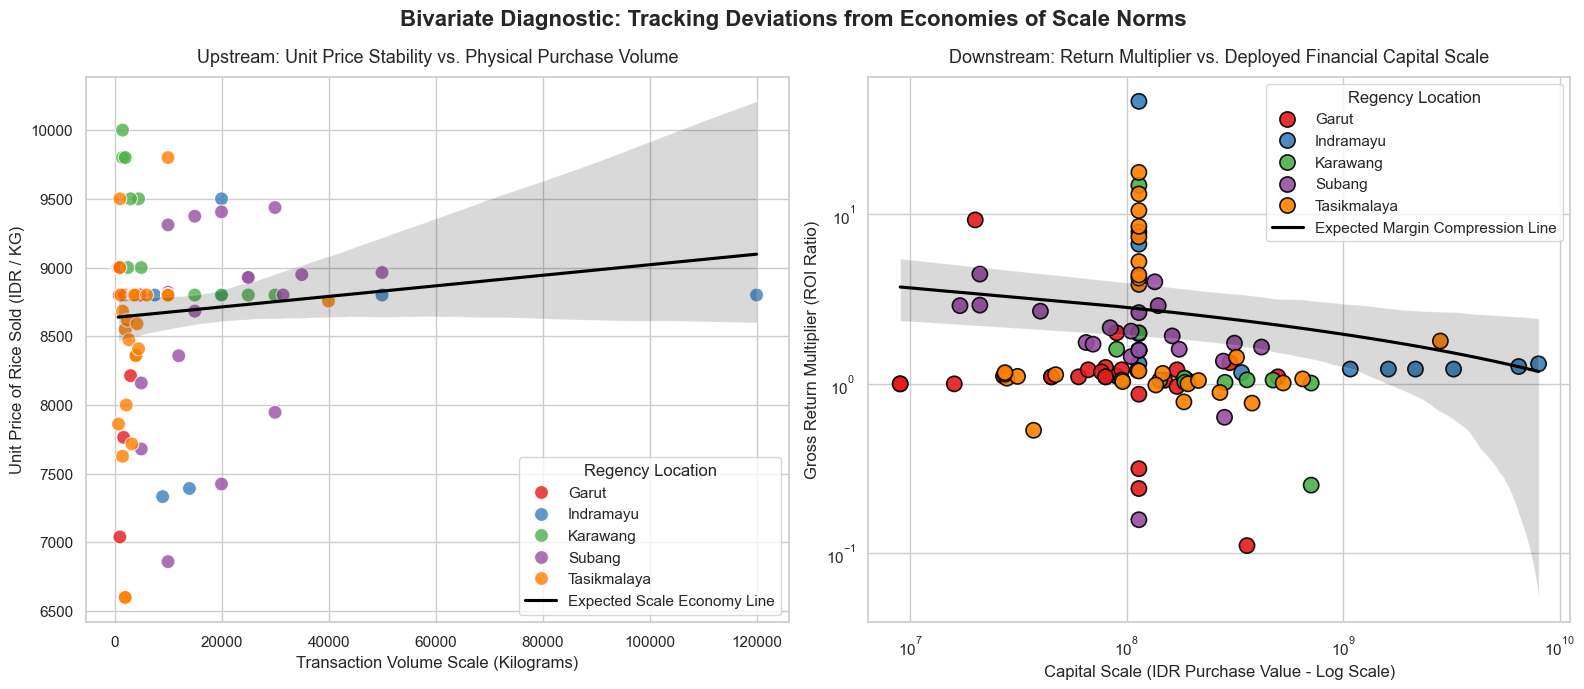

In [23]:
middlemen['unit_price_sold'] = middlemen['Value of rice sold (IDR)'] / middlemen['Total rice purchase (kg)']

# Wholesaler (Capital Scale)
wholesaler['roi_multiplier'] = wholesaler['Value of rice sold (IDR)'] / wholesaler['Value of rice purchase (IDR)']

# Set up side-by-side plotting canvas
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 13})

# =====================================================================
# PANEL 1: UPSTREAM PHYSICAL SCALE ECONOMY (Middlemen)
# =====================================================================
sns.scatterplot(
    data=middlemen,
    x='Total rice purchase (kg)',
    y='unit_price_sold',
    hue='Location',
    palette='Set1',
    s=100,
    alpha=0.8,
    ax=axes[0]
)
# Add a trendline to show the "Volume Norm" baseline
sns.regplot(
    data=middlemen,
    x='Total rice purchase (kg)',
    y='unit_price_sold',
    scatter=False,
    color='black',
    marker='--',
    ax=axes[0],
    label='Expected Scale Economy Line'
)
axes[0].set_title('Upstream: Unit Price Stability vs. Physical Purchase Volume', pad=10)
axes[0].set_xlabel('Transaction Volume Scale (Kilograms)')
axes[0].set_ylabel('Unit Price of Rice Sold (IDR / KG)')
axes[0].legend(title='Regency Location')

# =====================================================================
# PANEL 2: DOWNSTREAM CAPITAL SCALE ECONOMY (Wholesaler)
# =====================================================================
sns.scatterplot(
    data=wholesaler,
    x='Value of rice purchase (IDR)',
    y='roi_multiplier',
    hue='Location',
    palette='Set1',
    s=120,
    alpha=0.9,
    edgecolor='black',
    linewidth=1.2,
    ax=axes[1]
)
# Add a trendline to illustrate the systemic deviation from scale norms
sns.regplot(
    data=wholesaler,
    x='Value of rice purchase (IDR)',
    y='roi_multiplier',
    scatter=False,
    color='black',
    marker='--',
    logx=True, # Logarithmic fit captures power-law scaling accurately
    ax=axes[1],
    label='Expected Margin Compression Line'
)

axes[1].set_title('Downstream: Return Multiplier vs. Deployed Financial Capital Scale', pad=10)
axes[1].set_xlabel('Capital Scale (IDR Purchase Value - Log Scale)')
axes[1].set_ylabel('Gross Return Multiplier (ROI Ratio)')
axes[1].set_xscale('log') # Essential due to the multi-billion IDR variance
axes[1].set_yscale('log') # Essential to keep the 46.4x outlier from squishing the data
axes[1].legend(title='Regency Location')

plt.suptitle('Bivariate Diagnostic: Tracking Deviations from Economies of Scale Norms', fontsize=16, weight='bold', y=0.98)
plt.tight_layout()
plt.show()